# Diode Bayesian Inference with UltraNest


In [1]:
import copy
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
plt.style.use('default')

try:
    from optimpv import *
    from optimpv.models.Diodefits.DiodeAgent import DiodeAgent
    from optimpv.models.Diodefits.DiodeModel import NonIdealDiode_dark
    from optimpv.optimizers.BayesInfUltraNest.UltraNestOptimizer import UltraNestOptimizer
except Exception:
    sys.path.append('../..')
    from optimpv import *
    from optimpv.models.Diodefits.DiodeAgent import DiodeAgent
    from optimpv.models.Diodefits.DiodeModel import NonIdealDiode_dark
    from optimpv.optimizers.BayesInfUltraNest.UltraNestOptimizer import UltraNestOptimizer


## Problem Setup


In [2]:
params = []

J0 = FitParam(name = 'J0', value = 1e-5, bounds = [1e-6,1e-3], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$J_0$', unit='A m$^{-2}$', axis_type = 'log',force_log=True)
params.append(J0)

n = FitParam(name = 'n', value = 1.5, bounds = [1,2], log_scale = False, value_type = 'float', type='range', display_name=r'$n$', unit='', axis_type = 'linear')
params.append(n)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-5,1e-3], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$R_{\text{series}}$', unit=r'$\Omega$ m$^2$', axis_type = 'log',force_log=True)
params.append(R_series)

R_shunt = FitParam(name = 'R_shunt', value = 1e-1, bounds = [1e-2,1e2], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$R_{\text{shunt}}$', unit=r'$\Omega$ m$^2$', axis_type = 'log',force_log=True)
params.append(R_shunt)

# original values
params_orig = copy.deepcopy(params)
num_free_params = len([p for p in params if p.type != 'fixed'])


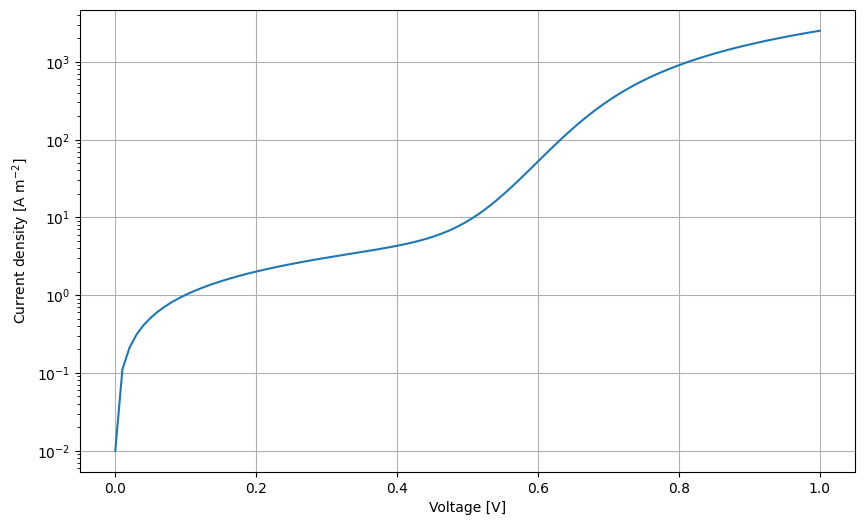

In [3]:
# Create JV to fit
X = np.linspace(0.001,1,100)
y = NonIdealDiode_dark(X, J0.value, n.value, R_series.value, R_shunt.value)

plt.figure(figsize=(10,6))
plt.semilogy(X,y)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.grid()
plt.show()


In [4]:
# Define the Agent and the target metric/loss function
metric = 'mse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'
exp_format = 'dark' # can be 'dark', 'light' depending on the type of data you have
use_pvlib = False # if True, use pvlib to calculate the diode model if not use the implementation in DiodeModel.py
diode = DiodeAgent(params, X, y, metric = metric, loss = loss, minimize=True,exp_format=exp_format,use_pvlib=use_pvlib,transforms='linear')

## Run UltraNest

If `ultranest` is not installed in the environment, the next cell will fail with an import error from the optimizer.


In [5]:

optimizer = UltraNestOptimizer(
    params=params,
    agents=diode,
    progress=True,
    log_dir='ultranest_logs/diode',
    resume='subfolder', # can be True, False, 'subfolder', or 'overwrite'
    name='diode',
    save_logs=False,
    run_kwargs={
        'min_num_live_points': 400,
        # 'dlogz': 0.5, 
        'min_ess': 100,
        'max_ncalls': 100000,
    },
)

results = optimizer.optimize()
optimizer.sampler.print_results()
best_params = optimizer.get_best_params(method='max_likelihood')
results


[INFO 04-27 13:34:44] optimpv.UltraNestOptimizer: Running UltraNest nested sampling...


----------------------------------------------------

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-0.005  -0.1823..-0.1818]*| it/evals=8320/93700 eff=8.9175% N=400        0   0    0 
[ultranest] Likelihood function evaluations: 93810
[ultranest]   logZ = -16.39 +- 0.13
[ultranest] Effective samples strategy satisfied (ESS = 2445.3, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.19 bs:0.13 tail:0.01 total:0.13 required:<0.50
[ultranest] done iterating.


[INFO 04-27 13:35:10] optimpv.UltraNestOptimizer: UltraNest run complete.
[INFO 04-27 13:35:10] optimpv.UltraNestOptimizer: $J_0$ (J0): 1.263e-05 (+8.15e-06 / -5.27e-06)
[INFO 04-27 13:35:10] optimpv.UltraNestOptimizer: $n$ (n): 1.52 (+0.0446 / -0.0462)
[INFO 04-27 13:35:10] optimpv.UltraNestOptimizer: $R_{\text{series}}$ (R_series): 9.969e-05 (+1.02e-06 / -1.09e-06)
[INFO 04-27 13:35:10] optimpv.UltraNestOptimizer: $R_{\text{shunt}}$ (R_shunt): 0.1592 (+1.75 / -0.0759)


----------------------------------------------------


logZ = -16.376 +- 0.338
  single instance: logZ = -16.376 +- 0.187
  bootstrapped   : logZ = -16.394 +- 0.338
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    J0                  : -5.95 │ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▆▇▆▆▄▅▃▂▂▁▁▁▁▁   ▁ │-3.94     -4.91 +- 0.23
    n                   : 1.329 │ ▁▁▁▁▁▁▁▁▂▂▃▃▄▆▆▇▇▇▇▆▆▄▄▃▂▂▁▁▁▁▁▁    ▁ │1.739     1.519 +- 0.046
    R_series            : -4.0234│ ▁ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▆▇▆▆▅▅▄▃▂▂▁▁▁▁▁▁▁▁ │-3.9834    -4.0014 +- 0.0046
    R_shunt             : -1.53 │ ▁▁▃▇▇▇▇▅▃▃▃▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁│2.00      -0.48 +- 0.79



{'J0': {'median': np.float64(1.2626367653125296e-05),
  '16th': np.float64(7.360958537331954e-06),
  '84th': np.float64(2.077179529546593e-05),
  'lower_err': np.float64(5.265409115793342e-06),
  'upper_err': np.float64(8.145427642340633e-06)},
 'n': {'median': np.float64(1.520097796175112),
  '16th': np.float64(1.473864506444571),
  '84th': np.float64(1.5646770754202572),
  'lower_err': np.float64(0.04623328973054108),
  'upper_err': np.float64(0.044579279245145154)},
 'R_series': {'median': np.float64(9.969283201397122e-05),
  '16th': np.float64(9.860620060196624e-05),
  '84th': np.float64(0.00010071233573366253),
  'lower_err': np.float64(1.0866314120049796e-06),
  'upper_err': np.float64(1.019503719691309e-06)},
 'R_shunt': {'median': np.float64(0.1592009462889993),
  '16th': np.float64(0.0833420196717666),
  '84th': np.float64(1.9134897630043686),
  'lower_err': np.float64(0.0758589266172327),
  'upper_err': np.float64(1.7542888167153692)}}

In [6]:
optimizer.sampler.print_results()


logZ = -16.376 +- 0.338
  single instance: logZ = -16.376 +- 0.187
  bootstrapped   : logZ = -16.394 +- 0.338
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    J0                  : -5.95 │ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▆▇▆▆▄▅▃▂▂▁▁▁▁▁   ▁ │-3.94     -4.91 +- 0.23
    n                   : 1.329 │ ▁▁▁▁▁▁▁▁▂▂▃▃▄▆▆▇▇▇▇▆▆▄▄▃▂▂▁▁▁▁▁▁    ▁ │1.739     1.519 +- 0.046
    R_series            : -4.0234│ ▁ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▆▇▆▆▅▅▄▃▂▂▁▁▁▁▁▁▁▁ │-3.9834    -4.0014 +- 0.0046
    R_shunt             : -1.53 │ ▁▁▃▇▇▇▇▅▃▃▃▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁│2.00      -0.48 +- 0.79



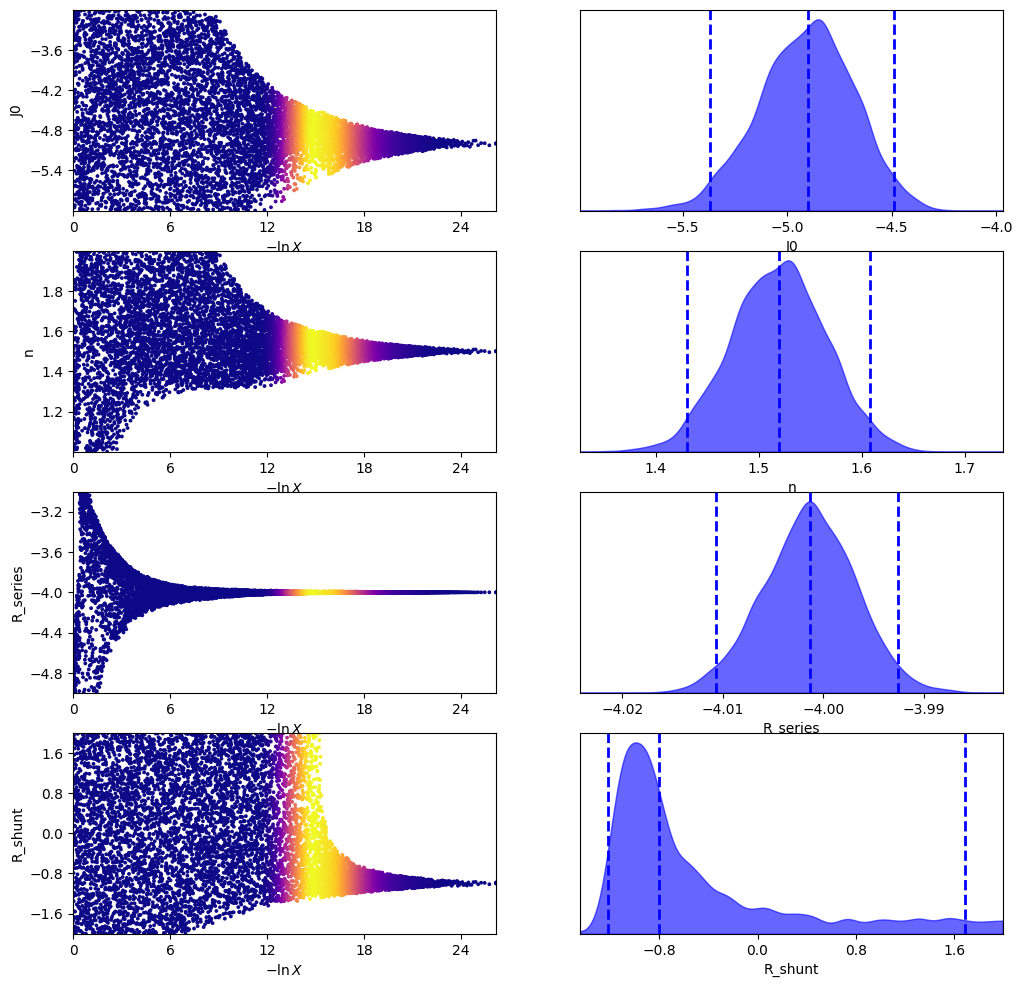

In [7]:
optimizer.sampler.plot_trace()

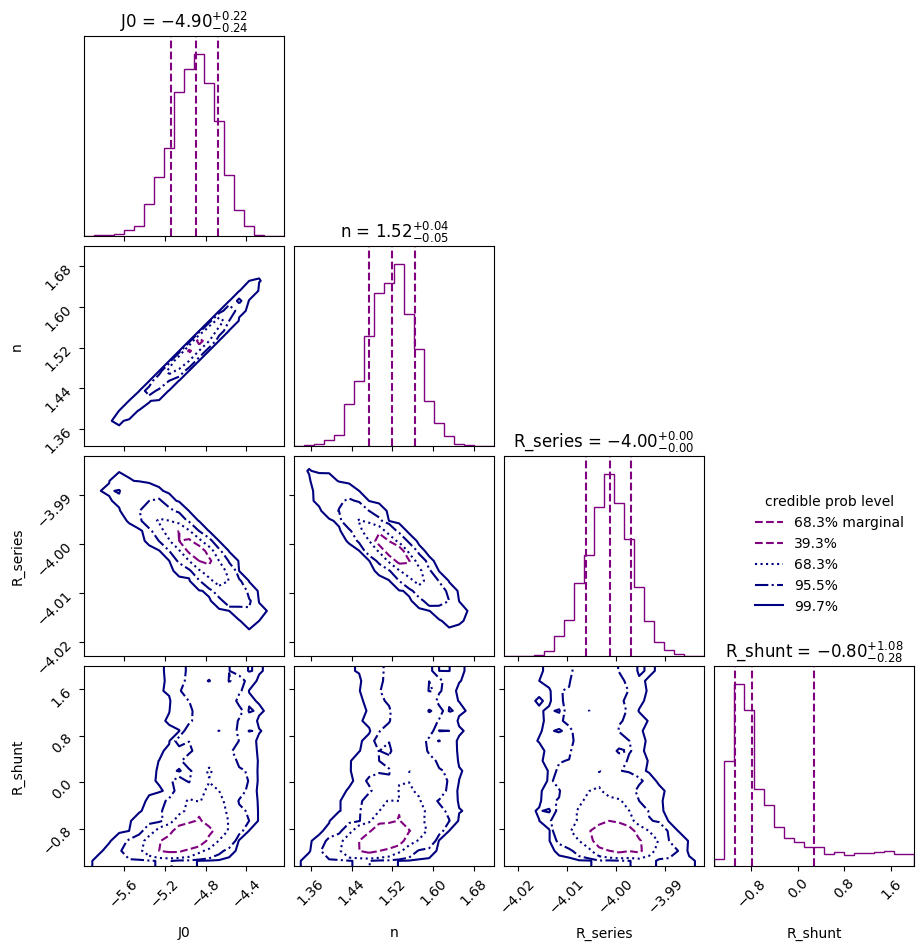

In [8]:
from ultranest.plot import cornerplot
plot = cornerplot(optimizer.nested_result)

In [9]:
summary_rows = []
for param in params:
    if param.type == 'fixed':
        continue
    summary_rows.append({
        'parameter': param.name,
        'best_fit': best_params[param.name],
        'posterior_median': results[param.name]['median'],
        '16th_percentile': results[param.name]['16th'],
        '84th_percentile': results[param.name]['84th'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,parameter,best_fit,posterior_median,16th_percentile,84th_percentile
0,J0,0.000010,0.000013,0.000007,0.000021
1,n,1.501303,1.520098,1.473865,1.564677
2,R_series,0.000100,0.000100,0.000099,0.000101
3,R_shunt,0.100047,0.159201,0.083342,1.913490


[{'name': 'J0', 'type': 'range', 'value_type': 'float', 'value': np.float64(1.0148700373820134e-05), 'bounds': [1e-06, 0.001], 'values': None, 'start_value': 1e-05, 'log_scale': False, 'fscale': 1, 'stepsize': None, 'rescale': False, 'display_name': '$J_0$', 'unit': 'A m$^{-2}$', 'full_name': '$J_0$ [A m$^{-2}$]', 'axis_type': 'log', 'std': None, 'encoding': None, 'is_ordered': False, 'is_sorted': False, 'force_log': True}, {'name': 'n', 'type': 'range', 'value_type': 'float', 'value': np.float64(1.501303365638245), 'bounds': [1, 2], 'values': None, 'start_value': 1.5, 'log_scale': False, 'fscale': 1, 'stepsize': None, 'rescale': False, 'display_name': '$n$', 'unit': '', 'full_name': '$n$', 'axis_type': 'linear', 'std': None, 'encoding': None, 'is_ordered': False, 'is_sorted': False, 'force_log': False}, {'name': 'R_series', 'type': 'range', 'value_type': 'float', 'value': np.float64(9.994995657342456e-05), 'bounds': [1e-05, 0.001], 'values': None, 'start_value': 0.0001, 'log_scale': F

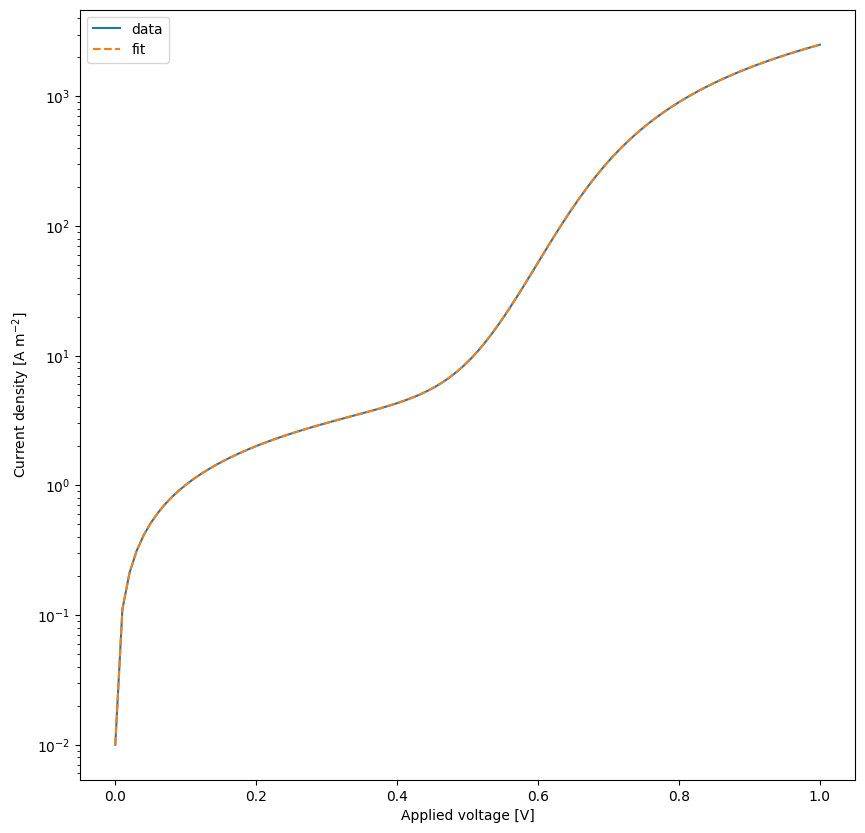

In [10]:
best_fit_params = copy.deepcopy(optimizer.params)
print(best_fit_params)
best_fit_agent = DiodeAgent(params, X, y, metric = metric, loss = loss, minimize=True,exp_format=exp_format,use_pvlib=use_pvlib,transforms='log')

yfit = best_fit_agent.run(parameters={})

plt.figure(figsize=(10,10))
plt.plot(X,y,label='data')
plt.plot(X,yfit,label='fit',linestyle='--')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Applied voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()
